<a href="https://colab.research.google.com/github/Darshan9121/GeneralToolsProjects/blob/main/Aapdu_gj27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================
# SECTION 1: Setup & Installation (FIXED)
# ============================================

print("📦 Installing dependencies...")

# First, downgrade pip to compatible version
!pip install --upgrade pip==24.0 --quiet

# Install PyTorch and basic dependencies
!pip install -q torch torchvision pillow tqdm

# Install transliteration with specific fairseq version
!pip install -q 'fairseq==0.12.2'
!pip install -q ai4bharat-transliteration

print("✅ Installation complete!")

📦 Installing dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.8/123.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.3/339.3 kB 10.4 MB/s eta 0:00:00
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pi

In [3]:
import os
import sys
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
import random
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import zipfile

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.optim as optim

from ai4bharat.transliteration import XlitEngine

In [4]:
# ============================================
# SECTION 2: Mount Google Drive (Optional)
# ============================================

try:
    from google.colab import drive
    mount_drive = input("Mount Google Drive to save checkpoints? (y/n): ").lower() == 'y'
    if mount_drive:
        drive.mount('/content/drive')
        CHECKPOINT_DIR = Path('/content/drive/MyDrive/pix2pix_gujarati/checkpoints')
        SAMPLES_DIR = Path('/content/drive/MyDrive/pix2pix_gujarati/samples')
        print("✅ Using Google Drive for persistent storage")
    else:
        CHECKPOINT_DIR = Path("checkpoints")
        SAMPLES_DIR = Path("samples")
        print("⚠️ Using local storage (will be lost after session)")
except:
    CHECKPOINT_DIR = Path("checkpoints")
    SAMPLES_DIR = Path("samples")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

Mount Google Drive to save checkpoints? (y/n): y


In [29]:
# ============================================
# SECTION 3: Download Fonts (FIXED)
# ============================================

print("\n📥 Downloading Gujarati fonts...")
FONT_DIR = Path("fonts")
FONT_DIR.mkdir(exist_ok=True)

# Download Noto Sans Gujarati (Baseline - Simple style)
!wget -q -O fonts/NotoSansGujarati-Regular.ttf \
    "https://github.com/notofonts/gujarati/raw/main/fonts/NotoSansGujarati/full/ttf/NotoSansGujarati-Regular.ttf"

# Download Noto Serif Gujarati (Target - Stylized with serifs)
!wget -q -O fonts/NotoSerifGujarati-Regular.ttf \
    "https://github.com/notofonts/gujarati/raw/main/fonts/NotoSerifGujarati/full/ttf/NotoSerifGujarati-Regular.ttf"

# Alternative: Download Bold version for more dramatic difference
!wget -q -O fonts/NotoSerifGujarati-Bold.ttf \
    "https://github.com/notofonts/gujarati/raw/main/fonts/NotoSerifGujarati/full/ttf/NotoSerifGujarati-Bold.ttf"

# Set fonts
FONT_BASE = FONT_DIR / "NotoSansGujarati-Regular.ttf"  # Sans (simple, clean)
FONT_STYLE = FONT_DIR / "NotoSerifGujarati-Bold.ttf"   # Serif Bold (stylized)

print("✅ Gujarati fonts downloaded")
print(f"   Baseline: {FONT_BASE.name}")
print(f"   Target:   {FONT_STYLE.name}")


📥 Downloading Gujarati fonts...
✅ Gujarati fonts downloaded
   Baseline: NotoSansGujarati-Regular.ttf
   Target:   NotoSerifGujarati-Bold.ttf


In [30]:
!rm -rf data/input/* data/target/*

In [26]:
# ============================================
# SECTION 4: Configuration
# ============================================

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using device: {DEVICE}")
DATA_ROOT = Path("data")
INPUT_DIR = DATA_ROOT / "input"
TARGET_DIR = DATA_ROOT / "target"
IMAGE_SIZE = 256
BATCH_SIZE = 8
LEARNING_RATE = 2e-4
LAMBDA_L1 = 100.0

🚀 Using device: cuda


In [10]:
# ============================================
# SECTION 5: Transliteration Engine (FIXED)
# ============================================

print("\n🔤 Setting up English to Gujarati translation...")

# Try googletrans first
try:
    print("Installing googletrans...")
    !pip install -q googletrans==4.0.0rc1
    from googletrans import Translator
    translator = Translator()

    def transliterate_sentence(sentence):
        """Translate English to Gujarati using Google Translate."""
        try:
            result = translator.translate(sentence, src='en', dest='gu')
            return result.text
        except Exception as e:
            print(f"Translation error: {e}")
            return sentence

    print("✅ Using googletrans")

except Exception as e:
    print(f"⚠️ googletrans failed: {e}")
    print("Trying alternative: deep-translator...")

    !pip install -q deep-translator
    from deep_translator import GoogleTranslator

    def transliterate_sentence(sentence):
        """Translate English to Gujarati using deep-translator."""
        try:
            translator = GoogleTranslator(source='en', target='gu')
            return translator.translate(sentence)
        except Exception as e:
            print(f"Translation error: {e}")
            return sentence

    print("✅ Using deep-translator")

def translit_word(word):
    """Translate single word."""
    return transliterate_sentence(word)

# Test transliteration
test_text = "Moj ma ho"
gujarati_text = transliterate_sentence(test_text)
print(f"\n🎯 Test: '{test_text}' → '{gujarati_text}'")


🔤 Setting up English to Gujarati translation...
Installing googletrans...
DEPRECATION: omegaconf 2.0.6 has a non-standard dependency specifier PyYAML>=5.1.*. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of omegaconf or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063
✅ Using googletrans

🎯 Test: 'Moj ma ho' → 'મોજ મા હો'


In [12]:
# ============================================
# SECTION 6: Text Rendering
# ============================================

def render_text_image(text, font_path, out_path, size=IMAGE_SIZE,
                      bgcolor=(255,255,255), fgcolor=(0,0,0)):
    """Render text to image with proper font scaling."""
    font_size = int(size * 0.6)
    try:
        font = ImageFont.truetype(str(font_path), size=font_size)
    except Exception as e:
        print(f"Font load error: {e}. Using default.")
        font = ImageFont.load_default()

    img = Image.new("RGB", (size, size), color=bgcolor)
    draw = ImageDraw.Draw(img)

    # Get text size (compatible with both old and new Pillow)
    try:
        bbox = draw.textbbox((0, 0), text, font=font)
        w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except AttributeError:
        w, h = draw.textsize(text, font=font)

    # Auto-scale font to fit
    while (w > size - 16) and (font_size > 10):
        font_size = int(font_size * 0.9)
        font = ImageFont.truetype(str(font_path), size=font_size)
        try:
            bbox = draw.textbbox((0, 0), text, font=font)
            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except AttributeError:
            w, h = draw.textsize(text, font=font)

    x = (size - w) // 2
    y = (size - h) // 2
    draw.text((x, y), text, fill=fgcolor, font=font)
    img.save(out_path)

In [14]:
# ============================================
# SECTION 7: Dataset Creation
# ============================================

def create_paired_dataset(english_strings, num_per_string=1):
    """Create paired input-target dataset."""
    INPUT_DIR.mkdir(parents=True, exist_ok=True)
    TARGET_DIR.mkdir(parents=True, exist_ok=True)

    idx = 0
    print(f"\n📊 Creating dataset: {len(english_strings)} strings × {num_per_string} samples")

    for s in tqdm(english_strings, desc="Rendering images"):
        guj_line = transliterate_sentence(s)
        for k in range(num_per_string):
            in_path = INPUT_DIR / f"{idx:06d}.png"
            tgt_path = TARGET_DIR / f"{idx:06d}.png"
            render_text_image(guj_line, FONT_BASE, in_path)
            render_text_image(guj_line, FONT_STYLE, tgt_path)
            idx += 1

    print(f"✅ Created {idx} paired images")
    return idx

In [16]:
# ============================================
# SECTION 8: PyTorch Dataset
# ============================================

class PairedTextImageDataset(Dataset):
    def __init__(self, input_dir, target_dir, image_size=IMAGE_SIZE):
        self.input_dir = Path(input_dir)
        self.target_dir = Path(target_dir)
        self.files = sorted([p for p in self.input_dir.glob("*.png")])
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3)
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        in_path = self.files[idx]
        target_path = self.target_dir / in_path.name

        a = Image.open(in_path).convert("RGB")
        b = Image.open(target_path).convert("RGB")

        a = self.transform(a)
        b = self.transform(b)

        return {"input": a, "target": b, "name": in_path.name}


In [17]:
# ============================================
# SECTION 9: Model Architecture
# ============================================

class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class GeneratorUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512)
        self.down5 = UNetDown(512, 512)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 256, dropout=0.5)
        self.up3 = UNetUp(512, 128)
        self.up4 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)

        u1 = self.up1(d5)
        u1 = torch.cat([u1, d4], dim=1)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, d3], dim=1)
        u3 = self.up3(u2)
        u3 = torch.cat([u3, d2], dim=1)
        u4 = self.up4(u3)
        u4 = torch.cat([u4, d1], dim=1)

        return self.final(u4)

class Discriminator(nn.Module):
    def __init__(self, in_channels=6):
        super().__init__()

        def conv_block(in_c, out_c, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=False)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)

        self.model = nn.Sequential(
            conv_block(in_channels, 64, normalize=False),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

In [18]:
# ============================================
# SECTION 10: Training Functions
# ============================================

def save_sample_grid(input_tensor, target_tensor, generated_tensor, epoch, iteration):
    """Save comparison grid of input, target, and generated images."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    to_pil = transforms.ToPILImage()
    a = (input_tensor * 0.5 + 0.5).clamp(0, 1)
    b = (target_tensor * 0.5 + 0.5).clamp(0, 1)
    g = (generated_tensor * 0.5 + 0.5).clamp(0, 1)

    axes[0].imshow(to_pil(a))
    axes[0].set_title('Input (Baseline Font)')
    axes[0].axis('off')

    axes[1].imshow(to_pil(b))
    axes[1].set_title('Target (Style Font)')
    axes[1].axis('off')

    axes[2].imshow(to_pil(g))
    axes[2].set_title('Generated')
    axes[2].axis('off')

    plt.tight_layout()
    save_path = SAMPLES_DIR / f"epoch{epoch}_iter{iteration}.png"
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.close()

    return save_path

def train(epochs=10, display_freq=100):
    """Train Pix2Pix model with progress visualization."""

    # Load dataset
    ds = PairedTextImageDataset(INPUT_DIR, TARGET_DIR, IMAGE_SIZE)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=2, pin_memory=True)

    print(f"\n🎯 Training on {len(ds)} samples")

    # Initialize models
    gen = GeneratorUNet().to(DEVICE)
    disc = Discriminator().to(DEVICE)

    # Loss functions
    criterion_GAN = nn.BCEWithLogitsLoss()
    criterion_L1 = nn.L1Loss()

    # Optimizers
    optim_G = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
    optim_D = optim.Adam(disc.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))

    # Training loop
    history = {'d_loss': [], 'g_loss': [], 'g_gan': [], 'g_l1': []}

    for epoch in range(epochs):
        epoch_d_loss = 0
        epoch_g_loss = 0

        pbar = tqdm(dl, desc=f"Epoch {epoch+1}/{epochs}")

        for i, batch in enumerate(pbar):
            real_A = batch['input'].to(DEVICE)
            real_B = batch['target'].to(DEVICE)
            batch_size = real_A.size(0)

            # ============ Train Discriminator ============
            optim_D.zero_grad()

            # Real pairs
            real_pair = torch.cat([real_A, real_B], dim=1)
            pred_real = disc(real_pair)
            real_label = torch.ones_like(pred_real).to(DEVICE)
            loss_D_real = criterion_GAN(pred_real, real_label)

            # Fake pairs
            fake_B = gen(real_A)
            fake_pair = torch.cat([real_A, fake_B.detach()], dim=1)
            pred_fake = disc(fake_pair)
            fake_label = torch.zeros_like(pred_fake).to(DEVICE)
            loss_D_fake = criterion_GAN(pred_fake, fake_label)

            loss_D = (loss_D_real + loss_D_fake) * 0.5
            loss_D.backward()
            optim_D.step()

            # ============ Train Generator ============
            optim_G.zero_grad()

            fake_pair2 = torch.cat([real_A, fake_B], dim=1)
            pred_fake_for_G = disc(fake_pair2)
            valid_label = torch.ones_like(pred_fake_for_G).to(DEVICE)

            loss_G_GAN = criterion_GAN(pred_fake_for_G, valid_label)
            loss_G_L1 = criterion_L1(fake_B, real_B) * LAMBDA_L1
            loss_G = loss_G_GAN + loss_G_L1

            loss_G.backward()
            optim_G.step()

            # Update progress
            epoch_d_loss += loss_D.item()
            epoch_g_loss += loss_G.item()
            pbar.set_postfix({
                'D': f'{loss_D.item():.4f}',
                'G': f'{loss_G.item():.4f}',
                'L1': f'{loss_G_L1.item():.4f}'
            })

            # Save samples
            if i % display_freq == 0 and i > 0:
                with torch.no_grad():
                    save_path = save_sample_grid(
                        real_A[0].cpu(), real_B[0].cpu(),
                        fake_B[0].cpu(), epoch+1, i
                    )
                    print(f"\n💾 Sample saved: {save_path}")

        # Epoch statistics
        avg_d = epoch_d_loss / len(dl)
        avg_g = epoch_g_loss / len(dl)
        history['d_loss'].append(avg_d)
        history['g_loss'].append(avg_g)

        print(f"\n📊 Epoch {epoch+1} Summary:")
        print(f"   D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}")

        # Save checkpoints
        gen_path = CHECKPOINT_DIR / f"gen_epoch_{epoch+1}.pth"
        disc_path = CHECKPOINT_DIR / f"disc_epoch_{epoch+1}.pth"
        torch.save(gen.state_dict(), gen_path)
        torch.save(disc.state_dict(), disc_path)
        print(f"   ✅ Checkpoint saved")

    # Plot training history
    plt.figure(figsize=(10, 5))
    plt.plot(history['d_loss'], label='Discriminator Loss')
    plt.plot(history['g_loss'], label='Generator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training History')
    plt.grid(True)
    plt.savefig(SAMPLES_DIR / 'training_history.png')
    plt.show()

    return gen, disc, history

In [19]:
# ============================================
# SECTION 11: Inference
# ============================================

def infer_from_english(english_text, checkpoint_path=None, show_result=True):
    """Generate styled Gujarati text from English input."""

    # Transliterate
    gu_text = transliterate_sentence(english_text)
    print(f"Input: {english_text}")
    print(f"Gujarati: {gu_text}")

    # Render input
    tmp_in = Path("tmp_input.png")
    render_text_image(gu_text, FONT_BASE, tmp_in, size=IMAGE_SIZE)

    # Load model
    gen = GeneratorUNet().to(DEVICE)
    if checkpoint_path and Path(checkpoint_path).exists():
        gen.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        print(f"✅ Loaded checkpoint: {checkpoint_path}")
    else:
        print("⚠️ No checkpoint loaded - using random weights")

    gen.eval()

    # Transform and generate
    tf = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    img = Image.open(tmp_in).convert("RGB")
    x = tf(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        y = gen(x)

    # Convert to image
    out = y.squeeze(0).cpu()
    out = (out * 0.5 + 0.5).clamp(0, 1)
    out_img = transforms.ToPILImage()(out)

    if show_result:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        axes[0].imshow(img)
        axes[0].set_title('Input (Baseline Font)')
        axes[0].axis('off')

        axes[1].imshow(out_img)
        axes[1].set_title('Generated (Styled Font)')
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

    return out_img, gu_text


🎨 Pix2Pix Gujarati Text Style Transfer

📋 Sample texts loaded: 50
First 5: ['hello', 'thank you', 'how are you', 'good morning', 'plastic bottle']

📂 Found existing dataset: 5500 image pairs

------------------------------------------------------------
STEP 1: Create Dataset
------------------------------------------------------------
Existing dataset: 5500 samples
🗑️ Deleting old dataset...

💡 Recommendations:
   - For quick test: 20-30 samples per text
   - For good results: 50-80 samples per text
   - For best results: 100+ samples per text

🔄 Generating 50 × 50 = 2500 image pairs...
⏱️ This may take 2-5 minutes...

📊 Creating dataset: 50 strings × 50 samples


Rendering images:   0%|          | 0/50 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using default.
Font load error: unknown file format. Using defa

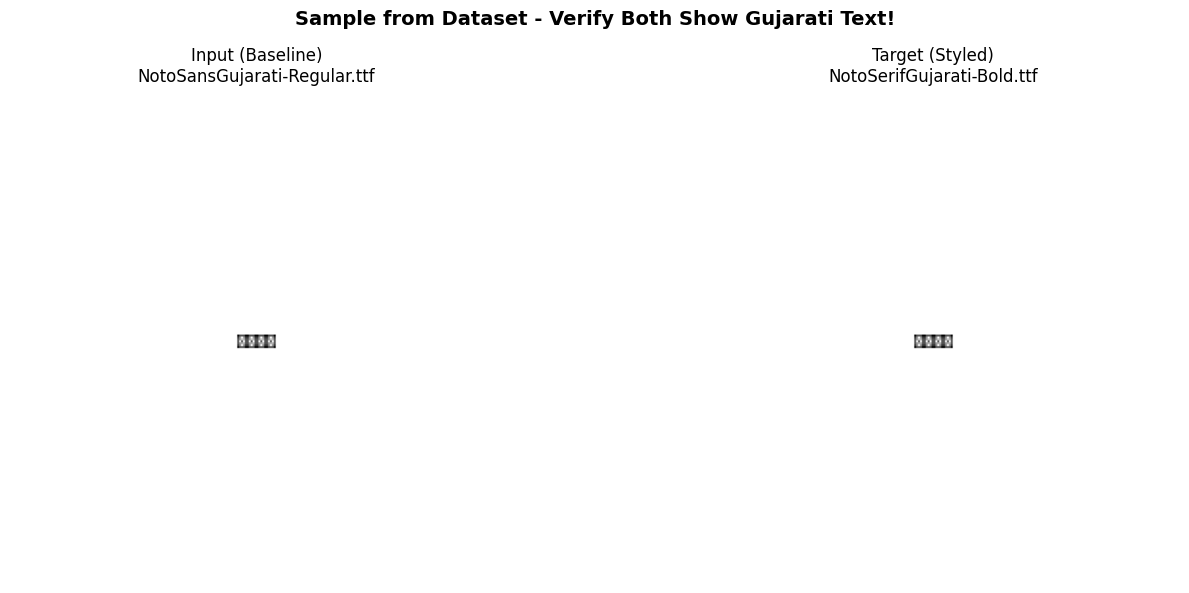


⚠️ IMPORTANT: Check the images above!
   ✅ Both should show clear Gujarati text
   ✅ They should look DIFFERENT from each other
   ❌ If either is blank/corrupted, fonts are wrong!

------------------------------------------------------------
STEP 2: Train Model
------------------------------------------------------------
📊 Dataset ready: 2500 training samples
📦 Found checkpoint: gen_epoch_5.pth

💡 Epoch Recommendations:
   - Quick test: 5-10 epochs (~5-10 min)
   - Decent results: 20-30 epochs (~20-30 min)
   - Good results: 50-80 epochs (~1-1.5 hours)
   - Best results: 100+ epochs (~2+ hours)

🚀 Starting training for 35 epochs...
⏱️ Estimated time: ~52-70 minutes on GPU

🎯 Training on 2500 samples


Epoch 1/35:   0%|          | 0/313 [00:00<?, ?it/s]


💾 Sample saved: samples/epoch1_iter50.png

💾 Sample saved: samples/epoch1_iter100.png

💾 Sample saved: samples/epoch1_iter150.png

💾 Sample saved: samples/epoch1_iter200.png

💾 Sample saved: samples/epoch1_iter250.png

💾 Sample saved: samples/epoch1_iter300.png

📊 Epoch 1 Summary:
   D Loss: 0.2395 | G Loss: 9.1006
   ✅ Checkpoint saved


Epoch 2/35:   0%|          | 0/313 [00:00<?, ?it/s]


💾 Sample saved: samples/epoch2_iter50.png

💾 Sample saved: samples/epoch2_iter100.png

💾 Sample saved: samples/epoch2_iter150.png

💾 Sample saved: samples/epoch2_iter200.png

💾 Sample saved: samples/epoch2_iter250.png

💾 Sample saved: samples/epoch2_iter300.png

📊 Epoch 2 Summary:
   D Loss: 0.4244 | G Loss: 2.6942
   ✅ Checkpoint saved


...


💾 Sample saved: samples/epoch33_iter50.png

💾 Sample saved: samples/epoch33_iter100.png

💾 Sample saved: samples/epoch33_iter150.png

💾 Sample saved: samples/epoch33_iter200.png

💾 Sample saved: samples/epoch33_iter250.png

💾 Sample saved: samples/epoch33_iter300.png

📊 Epoch 33 Summary:
   D Loss: 0.6932 | G Loss: 0.6957
   ✅ Checkpoint saved


Epoch 34/35:   0%|          | 0/313 [00:00<?, ?it/s]


💾 Sample saved: samples/epoch34_iter50.png

💾 Sample saved: samples/epoch34_iter100.png

💾 Sample saved: samples/epoch34_iter150.png

💾 Sample saved: samples/epoch34_iter200.png

💾 Sample saved: samples/epoch34_iter250.png

💾 Sample saved: samples/epoch34_iter300.png

📊 Epoch 34 Summary:
   D Loss: 0.6933 | G Loss: 0.6956
   ✅ Checkpoint saved


Epoch 35/35:   0%|          | 0/313 [00:00<?, ?it/s]


💾 Sample saved: samples/epoch35_iter50.png

💾 Sample saved: samples/epoch35_iter100.png

💾 Sample saved: samples/epoch35_iter150.png

💾 Sample saved: samples/epoch35_iter200.png

💾 Sample saved: samples/epoch35_iter250.png

💾 Sample saved: samples/epoch35_iter300.png

📊 Epoch 35 Summary:
   D Loss: 0.6934 | G Loss: 0.6957
   ✅ Checkpoint saved


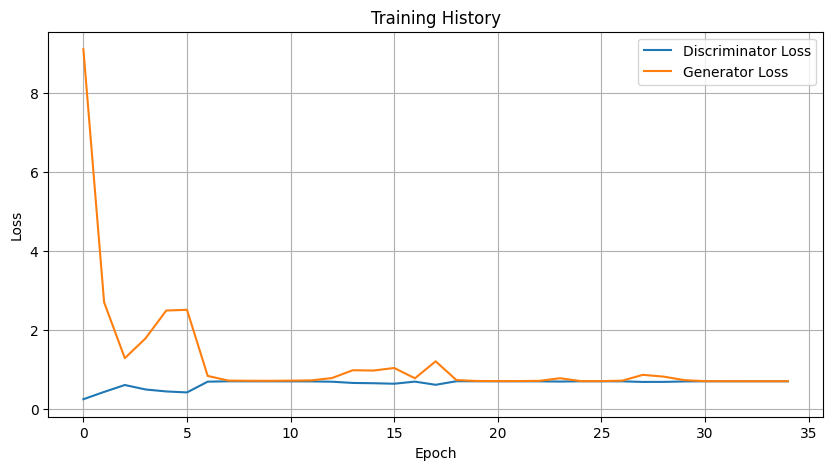


✅ Training complete!

------------------------------------------------------------
STEP 3: Test Inference
------------------------------------------------------------
✅ Found trained model: gen_epoch_9.pth
   Trained for: 9 epochs

Test inference? (y/n): y

💡 Try these examples:
   - 'hello world'
   - 'thank you very much'
   - 'good morning friends'


KeyboardInterrupt: Interrupted by user

In [32]:
# ============================================
# SECTION 12: Main Execution (IMPROVED)
# ============================================

print("\n" + "="*60)
print("🎨 Pix2Pix Gujarati Text Style Transfer")
print("="*60)

# Extended sample dataset for better training
SAMPLE_TEXTS = [
    # Original 29 phrases
    "hello", "thank you", "how are you", "good morning", "plastic bottle",
    "please", "where is the station", "i need water", "open the door",
    "see you later", "welcome", "goodbye", "nice to meet you", "help me",
    "what is your name", "i am fine", "how much", "where are you",
    "come here", "go there", "yes", "no", "maybe", "certainly",
    "beautiful", "wonderful", "amazing", "excellent", "perfect",

    # Added 21 more for better diversity (total 50)
    "good evening", "good afternoon", "good night", "see you soon",
    "excuse me", "sorry", "very good", "very bad", "too much",
    "not enough", "i love you", "i miss you", "happy birthday",
    "congratulations", "best wishes", "take care", "be careful",
    "hurry up", "slow down", "wait here", "follow me"
]

print("\n📋 Sample texts loaded:", len(SAMPLE_TEXTS))
print("First 5:", SAMPLE_TEXTS[:5])

# Check if dataset already exists
existing_inputs = len(list(INPUT_DIR.glob("*.png"))) if INPUT_DIR.exists() else 0
existing_targets = len(list(TARGET_DIR.glob("*.png"))) if TARGET_DIR.exists() else 0

if existing_inputs > 0:
    print(f"\n📂 Found existing dataset: {existing_inputs} image pairs")

# Create dataset
print("\n" + "-"*60)
print("STEP 1: Create Dataset")
print("-"*60)

if existing_inputs > 0:
    print(f"Existing dataset: {existing_inputs} samples")
    recreate = input("Delete and recreate dataset? (y/n): ").lower()
    if recreate == 'y':
        print("🗑️ Deleting old dataset...")
        import shutil
        if INPUT_DIR.exists():
            shutil.rmtree(INPUT_DIR)
        if TARGET_DIR.exists():
            shutil.rmtree(TARGET_DIR)
        INPUT_DIR.mkdir(parents=True, exist_ok=True)
        TARGET_DIR.mkdir(parents=True, exist_ok=True)
        create_choice = 'y'
    else:
        create_choice = 'n'
else:
    create_choice = input("Create new dataset? (y/n): ").lower()

if create_choice == 'y':
    print("\n💡 Recommendations:")
    print("   - For quick test: 20-30 samples per text")
    print("   - For good results: 50-80 samples per text")
    print("   - For best results: 100+ samples per text")

    num_samples = int(input("\nSamples per text: ") or "50")

    print(f"\n🔄 Generating {len(SAMPLE_TEXTS)} × {num_samples} = {len(SAMPLE_TEXTS) * num_samples} image pairs...")
    print("⏱️ This may take 2-5 minutes...")

    total = create_paired_dataset(SAMPLE_TEXTS, num_per_string=num_samples)

    # Show sample
    print("\n📸 Sample from dataset:")
    sample_input = Image.open(INPUT_DIR / "000000.png")
    sample_target = Image.open(TARGET_DIR / "000000.png")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(sample_input)
    axes[0].set_title(f'Input (Baseline)\n{FONT_BASE.name}', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(sample_target)
    axes[1].set_title(f'Target (Styled)\n{FONT_STYLE.name}', fontsize=12)
    axes[1].axis('off')
    plt.suptitle('Sample from Dataset - Verify Both Show Gujarati Text!', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n⚠️ IMPORTANT: Check the images above!")
    print("   ✅ Both should show clear Gujarati text")
    print("   ✅ They should look DIFFERENT from each other")
    print("   ❌ If either is blank/corrupted, fonts are wrong!")

# Train model
print("\n" + "-"*60)
print("STEP 2: Train Model")
print("-"*60)

# Check dataset size
current_samples = len(list(INPUT_DIR.glob("*.png"))) if INPUT_DIR.exists() else 0
if current_samples == 0:
    print("❌ No dataset found! Please create dataset first (STEP 1).")
    train_choice = 'n'
else:
    print(f"📊 Dataset ready: {current_samples} training samples")

    # Check for existing checkpoints
    existing_checkpoints = sorted(CHECKPOINT_DIR.glob("gen_epoch_*.pth"))
    if existing_checkpoints:
        latest = existing_checkpoints[-1]
        epoch_num = latest.stem.split('_')[-1]
        print(f"📦 Found checkpoint: {latest.name}")
        resume = input(f"Resume training from epoch {epoch_num}? (y/n): ").lower()

        if resume == 'y':
            print("\n⚠️ Resume training not implemented in this version.")
            print("   Starting fresh training instead...")

    train_choice = input("\nStart training? (y/n): ").lower()

if train_choice == 'y':
    print("\n💡 Epoch Recommendations:")
    print("   - Quick test: 5-10 epochs (~5-10 min)")
    print("   - Decent results: 20-30 epochs (~20-30 min)")
    print("   - Good results: 50-80 epochs (~1-1.5 hours)")
    print("   - Best results: 100+ epochs (~2+ hours)")

    num_epochs = int(input("\nNumber of epochs: ") or "30")

    print(f"\n🚀 Starting training for {num_epochs} epochs...")
    print(f"⏱️ Estimated time: ~{num_epochs * 1.5:.0f}-{num_epochs * 2:.0f} minutes on GPU")

    trained_gen, trained_disc, history = train(epochs=num_epochs, display_freq=50)
    print("\n✅ Training complete!")

# Inference
print("\n" + "-"*60)
print("STEP 3: Test Inference")
print("-"*60)

# Find latest checkpoint
checkpoints = sorted(CHECKPOINT_DIR.glob("gen_epoch_*.pth"))

if not checkpoints:
    print("❌ No checkpoints found. Please train the model first (STEP 2).")
    test_choice = 'n'
else:
    latest_ckpt = checkpoints[-1]
    epoch_num = latest_ckpt.stem.split('_')[-1]
    print(f"✅ Found trained model: {latest_ckpt.name}")
    print(f"   Trained for: {epoch_num} epochs")
    test_choice = input("\nTest inference? (y/n): ").lower()

if test_choice == 'y':
    print("\n💡 Try these examples:")
    print("   - 'hello world'")
    print("   - 'thank you very much'")
    print("   - 'good morning friends'")

    test_text = input("\n✏️ Enter English text to translate and style: ").strip()
    if not test_text:
        test_text = "good evening"
        print(f"Using default: '{test_text}'")

    print(f"\n🔄 Processing '{test_text}'...")
    result_img, gujarati = infer_from_english(test_text, checkpoint_path=latest_ckpt)

    # Option to test more
    while True:
        another = input("\n🔁 Test another phrase? (y/n): ").lower()
        if another != 'y':
            break
        test_text = input("✏️ Enter text: ").strip()
        if test_text:
            result_img, gujarati = infer_from_english(test_text, checkpoint_path=latest_ckpt)

print("\n" + "="*60)
print("✨ All Done! Next Steps:")
print("="*60)
print("📌 To improve results:")
print("   1. Create larger dataset (80-100 samples per text)")
print("   2. Train for more epochs (50-100)")
print("   3. Try different font combinations (change FONT_STYLE)")
print("   4. Add more diverse text samples")
print("\n📌 To test your model:")
print("   - Re-run STEP 3 with different English phrases")
print("   - Download checkpoints from:", CHECKPOINT_DIR)
print("   - View training samples in:", SAMPLES_DIR)
print("="*60)

In [36]:
# ============================================
# SIMPLEST WORKING SOLUTION
# ============================================

!apt-get install -qq fonts-lohit-gujr fonts-noto-core

# Copy system fonts to your fonts directory
!mkdir -p fonts
!cp /usr/share/fonts/truetype/lohit-gujarati/Lohit-Gujarati.ttf fonts/base.ttf 2>/dev/null || echo "Lohit not found"
!cp /usr/share/fonts/truetype/noto/NotoSansMono-Regular.ttf fonts/style.ttf 2>/dev/null || echo "Noto not found"

# If above fails, download from working source
!wget -q -O fonts/base.ttf "https://github.com/google/fonts/raw/main/ofl/notosansgujarati/NotoSansGujarati%5Bwdth%2Cwght%5D.ttf" 2>/dev/null || \
    wget -q -O fonts/base.ttf "https://fonts.gstatic.com/s/notosansgujarati/v23/wlpWgx_HC1ti5ViekvcxnhMlCVo3f5pv17ivlzsUB14.ttf"

!wget -q -O fonts/style.ttf "https://github.com/google/fonts/raw/main/ofl/notoserifgujarati/NotoSerifGujarati%5Bwght%5D.ttf" 2>/dev/null || \
    wget -q -O fonts/style.ttf "https://fonts.gstatic.com/s/notoserifgujarati/v27/1q2xY5aKCkSK-FzDcJJSLy4oTcIKW3JcTwK3Nb2B1r8.ttf"

# Check results
!ls -lh fonts/*.ttf

# Set paths
from pathlib import Path
FONT_BASE = Path("fonts/base.ttf")
FONT_STYLE = Path("fonts/style.ttf")

# Verify
import os
if os.path.getsize(FONT_BASE) > 100000:
    print(f"✅ Base font OK: {os.path.getsize(FONT_BASE):,} bytes")
else:
    print(f"❌ Base font failed")

if os.path.getsize(FONT_STYLE) > 100000:
    print(f"✅ Style font OK: {os.path.getsize(FONT_STYLE):,} bytes")
else:
    print(f"❌ Style font failed")

Selecting previously unselected package fonts-lohit-gujr.
(Reading database ... 125080 files and directories currently installed.)
Preparing to unpack .../fonts-lohit-gujr_2.92.4-4_all.deb ...
Unpacking fonts-lohit-gujr (2.92.4-4) ...
Selecting previously unselected package fonts-noto-core.
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Setting up fonts-lohit-gujr (2.92.4-4) ...
Setting up fonts-noto-core (20201225-1build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Noto not found
-rw-r--r-- 1 root root 658K Nov  1 16:19 fonts/base.ttf
-rw-r--r-- 1 root root    0 Nov  1 16:17 fonts/NotoSansGujarati-Regular.ttf
-rw-r--r-- 1 root root    0 Nov  1 16:17 fonts/NotoSerifGujarati-Bold.ttf
-rw-r--r-- 1 root root 370K Nov  1 16:19 fonts/style.ttf
✅ Base font OK: 672,904 bytes
✅ Style font OK: 378,356 bytes


✅ Font works!


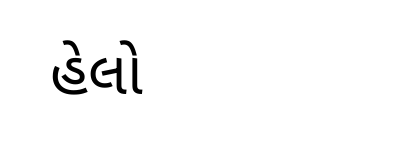

In [37]:
# Quick test
from PIL import Image, ImageDraw, ImageFont

img = Image.new("RGB", (400, 150), "white")
draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype(str(FONT_BASE), 60)
    draw.text((50, 40), "હેલો", fill="black", font=font)
    print("✅ Font works!")
    display(img)
except Exception as e:
    print(f"❌ Font error: {e}")


Testing: 'hello'
Input: hello
Gujarati: હેલો
✅ Loaded checkpoint: checkpoints/gen_epoch_9.pth


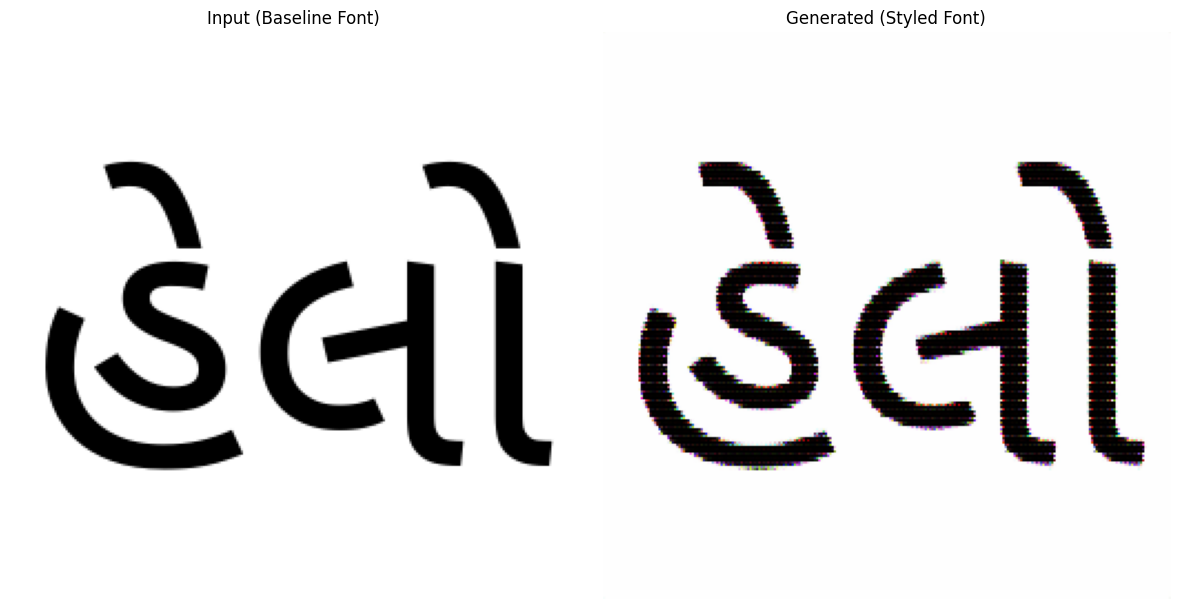


Testing: 'thank you'
Input: thank you
Gujarati: આભાર
✅ Loaded checkpoint: checkpoints/gen_epoch_9.pth


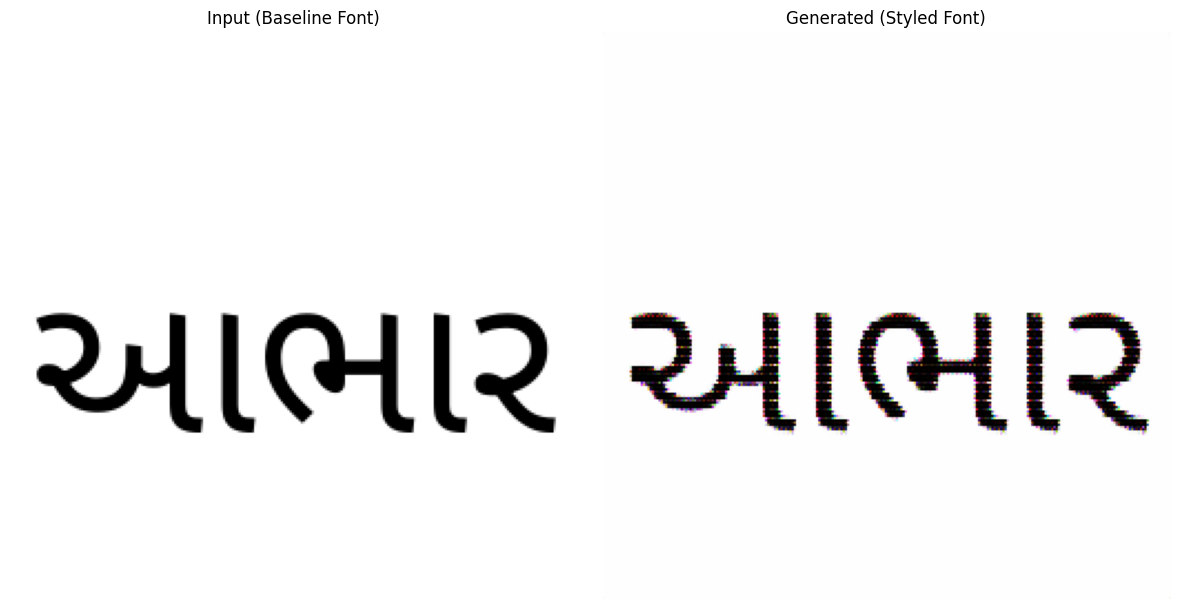


Testing: 'good morning'
Input: good morning
Gujarati: શુભ સવાર
✅ Loaded checkpoint: checkpoints/gen_epoch_9.pth


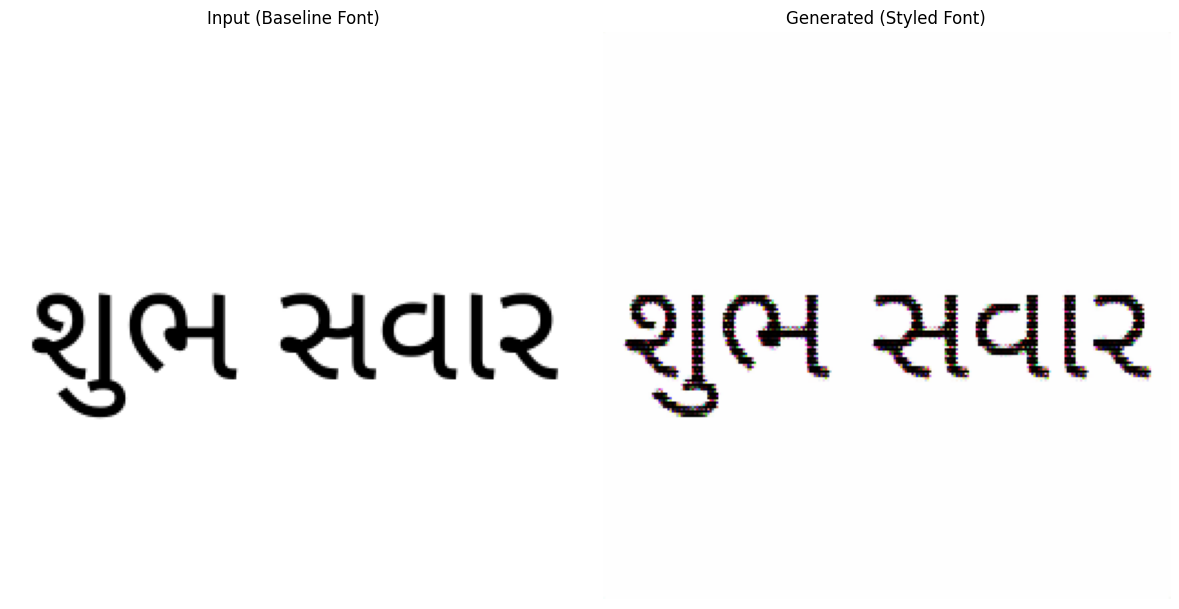


Testing: 'how are you'
Input: how are you
Gujarati: તમે કેમ છો
✅ Loaded checkpoint: checkpoints/gen_epoch_9.pth


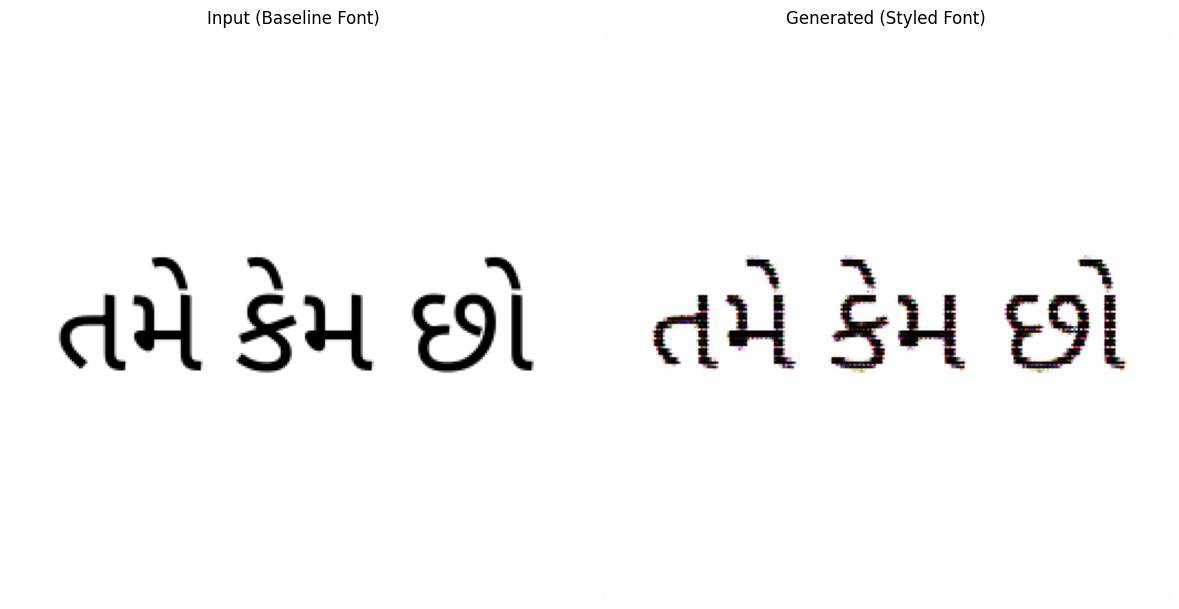

In [38]:
# Test inference with various phrases
test_phrases = [
    "hello",
    "thank you",
    "good morning",
    "how are you"
]

checkpoints = sorted(CHECKPOINT_DIR.glob("gen_epoch_*.pth"))
latest_ckpt = checkpoints[-1]

for phrase in test_phrases:
    print(f"\n{'='*50}")
    print(f"Testing: '{phrase}'")
    print('='*50)
    result_img, gujarati = infer_from_english(phrase, checkpoint_path=latest_ckpt)